In [34]:
import sys
sys.path.insert(0, "..")

import pandas as pd

from lightgbm import LGBMRegressor
import lightgbm as lgb

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

In [2]:
!ls ../data/datasets/daily/*

../data/datasets/daily/dataset_level_01_daily_total.parquet
../data/datasets/daily/dataset_level_02_daily_state.parquet
../data/datasets/daily/dataset_level_03_daily_cat.parquet
../data/datasets/daily/dataset_level_04_daily_dept.parquet
../data/datasets/daily/dataset_level_05_daily_state_cat.parquet
../data/datasets/daily/dataset_level_06_daily_store.parquet
../data/datasets/daily/dataset_level_07_daily_state_dept.parquet
../data/datasets/daily/dataset_level_08_daily_store_cat.parquet
../data/datasets/daily/dataset_level_09_daily_store_dept.parquet
../data/datasets/daily/dataset_level_10_daily_item__FOODS_1.parquet
../data/datasets/daily/dataset_level_10_daily_item__FOODS_2.parquet
../data/datasets/daily/dataset_level_10_daily_item__FOODS_3.parquet
../data/datasets/daily/dataset_level_10_daily_item__HOBBIES_1.parquet
../data/datasets/daily/dataset_level_10_daily_item__HOBBIES_2.parquet
../data/datasets/daily/dataset_level_10_daily_item__HOUSEHOLD_1.parquet
../data/datasets/daily/datase

# Data

In [ ]:
LEVEL = 'level_11_daily_item_state__CA_FOODS_1'
GRAIN = 'daily'
OBJECTIVE = "tweedie"

In [ ]:
DATASET_PATH = f'../data/datasets/{GRAIN}/{LEVEL}parquet'

SEASON_LENGTH = {"daily": 7, "weekly": 52}[GRAIN]

VALID_PERIODS = 365 if GRAIN == "daily" else 52
TEST_PERIODS = 28 if GRAIN == "daily" else 4

df = pd.read_parquet(DATASET_PATH)

df = df.sort_values(['agg_id', 'date'])

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,FOODS_1_FOODS_FOODS_1_001_CA,FOODS_1_001,FOODS_1,FOODS,TOTAL,CA,2011-01-29,6.0,12.0,2.0,NaN,NaN,0.923127,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,31.0,68.0,105.0,157.0,194.0,236.0,1473.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.000000,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FOODS_1_FOODS_FOODS_1_001_CA,FOODS_1_001,FOODS_1,FOODS,TOTAL,CA,2011-01-30,3.0,6.0,2.0,NaN,NaN,0.923127,0,0,0,NaN,NaN,NaN,NaN,2011,1,30,6,4,1,33.0,73.0,108.0,162.0,204.0,241.0,1475.0,1.0,1,NaN,7.0,NaN,0,0,1,0,0,0,-0.781832,0.623490,0.0,1.000000,0.478434,0.878124,0.0,NaN,298.0,NaN,336.0,0.0,0.0,0.0,0.000000,NaN,0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FOODS_1_FOODS_FOODS_1_001_CA,FOODS_1_001,FOODS_1,FOODS,TOTAL,CA,2011-01-31,2.0,4.0,2.0,NaN,NaN,0.923127,0,0,0,NaN,NaN,NaN,NaN,2011,1,31,0,5,0,33.0,77.0,110.0,161.0,210.0,240.0,1477.0,1.0,2,NaN,6.0,NaN,0,0,1,0,1,0,0.000000,1.000000,0.0,1.000000,0.493468,0.869764,0.0,NaN,297.0,NaN,335.0,0.0,0.0,0.0,0.500000,0.222222,0,3.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FOODS_1_FOODS_FOODS_1_001_CA,FOODS_1_001,FOODS_1,FOODS,TOTAL,CA,2011-02-01,3.0,6.0,2.0,NaN,NaN,0.923127,0,0,1,NaN,NaN,NaN,NaN,2011,2,1,1,5,0,32.0,79.0,111.0,162.0,211.0,238.0,1479.0,1.0,3,NaN,5.0,NaN,0,0,1,1,0,0,0.781832,0.623490,0.5,0.866025,0.508356,0.861147,0.0,NaN,

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 419256 entries, 0 to 419255
Columns: 115 entries, agg_id to rolling_mean_lag365_window_size91
dtypes: category(10), datetime64[ms](1), float32(87), int16(1), int32(1), int8(15)
memory usage: 155.5 MB


# Variables

In [6]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

CATEGORICAL_FEATURES = [
    c for c in [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
    ] if c in df.columns
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES), "features_disponibles")

104 features_disponibles


# Split

In [7]:
from src.data import date_split

TEST_DAYS = TEST_PERIODS if GRAIN == "daily" else TEST_PERIODS * 7
VALID_DAYS = VALID_PERIODS if GRAIN == "daily" else VALID_PERIODS * 7

data_split = date_split(df, valid_days=VALID_DAYS, test_days=TEST_DAYS)

train, valid, test = data_split.train, data_split.valid, data_split.test
first_date, last_date = data_split.first_date, data_split.last_date
valid_start, test_start = data_split.valid_start, data_split.test_start

data_split.log_summary()

2026-08-23 17:46:09.852 | INFO     | src.data.split:log_summary:40 - Train : 2011-01-29 to 2015-04-26 (1,548 days, 334,368 rows)
2026-08-23 17:46:09.852 | INFO     | src.data.split:log_summary:41 - Valid : 2015-04-26 to 2016-04-25 (365 days, 78,840 rows)
2026-08-23 17:46:09.853 | INFO     | src.data.split:log_summary:42 - Test  : 2016-04-25 to 2016-05-22 (28 days, 6,048 rows)


In [8]:
import gc
from src.data import build_feature_matrices

X_train, y_train, X_valid, y_valid, X_test, y_test = build_feature_matrices(
    df, data_split, FEATURES, CATEGORICAL_FEATURES, TARGET,
)

eval_cols = [c for c in ["agg_id", "date", "sales", "gross_sales", "avg_sell_price", "is_store_closed"]
             if c in df.columns]
train = train[eval_cols].copy()
valid = valid[eval_cols].copy()
test = test[eval_cols].copy()

del df, data_split
gc.collect()

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")

Cantidad features: 104 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [9]:
import time

from src.evaluation import evaluate_predictions

model_results = []
predictions_valid = {}

def evaluate_model(name, y_pred_valid, fit_time=None, category=None):
    result = evaluate_predictions(train, valid, y_valid, y_pred_valid, name, fit_time=fit_time, category=category)
    model_results.append(result)
    predictions_valid[name] = y_pred_valid
    return result

## Baseline models

In [10]:
from src.modeling import seasonal_naive, drift, historical_mean, moving_average

In [11]:
SN_WINDOWS = {"daily": [1, 7, 28, 364], "weekly": [1, 4, 52]}[GRAIN]

for window in SN_WINDOWS:
    t0 = time.perf_counter()
    y_pred_sn= seasonal_naive(train, valid, TARGET, season_length=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Naive ({window}{GRAIN[0]})", y_pred_sn, fit_time=fit_time, category="Naive")

2026-08-23 17:46:10.700 | INFO     | src.evaluation.metrics:evaluate_predictions:354 -        Naive (1d) [Naive] | WAPE: 79.25% | WRMSSE: 1.2086 | MAE: 5.132 | RMSE: 8.524 | MAPE: 6308472953.95% | SMAPE: 89.58% | Bias: 14.30% | RMSLE: 1.0632 | TS: -14221.53 | SPEC: 34711.065 | MASE: 1.4677 | fit: 0.17s
2026-08-23 17:46:11.251 | INFO     | src.evaluation.metrics:evaluate_predictions:354 -        Naive (7d) [Naive] | WAPE: 68.26% | WRMSSE: 1.1491 | MAE: 4.420 | RMSE: 7.556 | MAPE: 4131532290.68% | SMAPE: 91.74% | Bias: -18.00% | RMSLE: 1.0293 | TS: 20794.12 | SPEC: 26591.020 | MASE: 1.2954 | fit: 0.19s
2026-08-23 17:46:11.789 | INFO     | src.evaluation.metrics:evaluate_predictions:354 -       Naive (28d) [Naive] | WAPE: 72.28% | WRMSSE: 1.2266 | MAE: 4.680 | RMSE: 8.013 | MAPE: 5102232448.32% | SMAPE: 92.70% | Bias: -8.18% | RMSLE: 1.0390 | TS: 8926.38 | SPEC: 8554.961 | MASE: 1.3681 | fit: 0.17s
2026-08-23 17:46:12.320 | INFO     | src.evaluation.metrics:evaluate_predictions:354 -     

### Drift

In [12]:
t0 = time.perf_counter()
y_pred_drift = drift(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Drift", y_pred_drift, fit_time=fit_time, category="Naive")

2026-08-23 17:46:12.748 | INFO     | src.evaluation.metrics:evaluate_predictions:354 -             Drift [Naive] | WAPE: 85.11% | WRMSSE: 1.2759 | MAE: 5.511 | RMSE: 9.206 | MAPE: 6811250059.59% | SMAPE: 97.65% | Bias: 18.05% | RMSLE: 1.0922 | TS: -16725.42 | SPEC: 35660.494 | MASE: 1.5662 | fit: 0.05s


{'model': 'Drift',
 'category': 'Naive',
 'wape': 0.8510587973137157,
 'wrmsse': 1.2758550243990665,
 'mae': 5.510810813026768,
 'rmse': 9.205761918526223,
 'mape': 68112500.59592104,
 'smape': 0.9764916064667476,
 'bias': 0.18054692384460336,
 'rmsle': 1.0921638320365823,
 'tracking_signal': -16725.424284241904,
 'spec': 35660.49446965673,
 'mase': 1.5662035012761981,
 'fit_time': 0.04963575600049808}

### Historical mean

In [13]:
t0 = time.perf_counter()
y_pred_mean = historical_mean(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Historical mean", y_pred_mean, fit_time=fit_time, category="Naive")

2026-08-23 17:46:13.136 | INFO     | src.evaluation.metrics:evaluate_predictions:354 -   Historical mean [Naive] | WAPE: 60.64% | WRMSSE: 1.0278 | MAE: 3.926 | RMSE: 6.549 | MAPE: 6293686944.57% | SMAPE: 87.52% | Bias: -14.54% | RMSLE: 0.8515 | TS: 18903.36 | SPEC: 22279.398 | MASE: 1.1648 | fit: 0.01s


{'model': 'Historical mean',
 'category': 'Naive',
 'wape': 0.6063587628152884,
 'wrmsse': 1.027814560954454,
 'mae': 3.926319118306789,
 'rmse': 6.5490461213041495,
 'mape': 62936869.44573615,
 'smape': 0.8752237434819818,
 'bias': -0.1453857922307989,
 'rmsle': 0.8514944913141012,
 'tracking_signal': 18903.356498482488,
 'spec': 22279.39777012444,
 'mase': 1.1648459336110732,
 'fit_time': 0.006733086000167532}

### Moving average

In [14]:
MA_WINDOWS = {"daily": [7, 14, 21, 28, 35], "weekly": [2, 3, 4, 6, 8,]}[GRAIN]

for window in MA_WINDOWS:
    t0 = time.perf_counter()
    y_pred_ma = moving_average(train, valid, TARGET, window=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Moving average ({window}{GRAIN[0]})", y_pred_ma, fit_time=fit_time, category="Naive")

2026-08-23 17:46:13.549 | INFO     | src.evaluation.metrics:evaluate_predictions:354 - Moving average (7d) [Naive] | WAPE: 60.07% | WRMSSE: 0.9881 | MAE: 3.890 | RMSE: 6.932 | MAPE: 4229542715.34% | SMAPE: 84.02% | Bias: -17.99% | RMSLE: 0.9075 | TS: 23614.88 | SPEC: 26541.231 | MASE: 1.1213 | fit: 0.03s
2026-08-23 17:46:13.950 | INFO     | src.evaluation.metrics:evaluate_predictions:354 - Moving average (14d) [Naive] | WAPE: 58.95% | WRMSSE: 0.9675 | MAE: 3.817 | RMSE: 6.605 | MAPE: 4433373257.12% | SMAPE: 83.69% | Bias: -16.27% | RMSLE: 0.8732 | TS: 21753.36 | SPEC: 15024.191 | MASE: 1.1013 | fit: 0.03s
2026-08-23 17:46:14.344 | INFO     | src.evaluation.metrics:evaluate_predictions:354 - Moving average (21d) [Naive] | WAPE: 58.94% | WRMSSE: 0.9629 | MAE: 3.817 | RMSE: 6.587 | MAPE: 4822521863.92% | SMAPE: 83.63% | Bias: -14.75% | RMSLE: 0.8548 | TS: 19729.52 | SPEC: 11299.370 | MASE: 1.0976 | fit: 0.03s
2026-08-23 17:46:14.747 | INFO     | src.evaluation.metrics:evaluate_predictions

## Modelos estadísticos clásicos

Familias de forecasting estadístico clásico, ajustadas serie por serie (sin usar la matriz de features de ML). SARIMA es el modelo más citado en la literatura académica; ETS/Holt-Winters es rápido y robusto (base de benchmarks M4/M5); Theta ganó la M3 pese a su simplicidad; TBATS extiende ETS para estacionalidades múltiples; Prophet (Meta) es popular en industria por ser fácil de tunear.

In [ ]:
from src.modeling import fit_sarima, fit_ets, fit_theta, fit_tbats, fit_prophet

### SARIMA

In [ ]:
t0 = time.perf_counter()
y_pred_sarima = fit_sarima(train, valid, TARGET, seasonal_order=(1, 1, 1, SEASON_LENGTH))
fit_time = time.perf_counter() - t0

evaluate_model("SARIMA", y_pred_sarima, fit_time=fit_time, category="Statistical")

### ETS (Holt-Winters)

In [ ]:
t0 = time.perf_counter()
y_pred_ets = fit_ets(train, valid, TARGET, seasonal_periods=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("ETS (Holt-Winters)", y_pred_ets, fit_time=fit_time, category="Statistical")

### Theta

In [ ]:
t0 = time.perf_counter()
y_pred_theta = fit_theta(train, valid, TARGET, period=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("Theta", y_pred_theta, fit_time=fit_time, category="Statistical")

### TBATS

In [ ]:
t0 = time.perf_counter()
y_pred_tbats = fit_tbats(train, valid, TARGET, season_length=(SEASON_LENGTH,))
fit_time = time.perf_counter() - t0

evaluate_model("TBATS", y_pred_tbats, fit_time=fit_time, category="Statistical")

### Prophet

In [ ]:
t0 = time.perf_counter()
y_pred_prophet = fit_prophet(train, valid, TARGET, weekly_seasonality=(GRAIN == "daily"))
fit_time = time.perf_counter() - t0

evaluate_model("Prophet", y_pred_prophet, fit_time=fit_time, category="Statistical")

## Modelos Machine Learning

In [16]:
from src.modeling import fit_lightgbm, fit_xgboost, fit_catboost, catboost_features, fit_histgb, histgb_features, fit_ridge

### LightGBM

In [17]:
t0 = time.perf_counter()
lgbm_model = fit_lightgbm(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM", lgbm_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 17:46:27.914 | INFO     | src.evaluation.metrics:evaluate_predictions:354 -             LightGBM [ML] | WAPE: 39.57% | WRMSSE: 0.7417 | MAE: 2.562 | RMSE: 4.430 | MAPE: 246792121.51% | SMAPE: 74.31% | Bias: -1.06% | RMSLE: 0.4604 | TS: 2104.99 | SPEC: 733.530 | MASE: 0.7847 | fit: 2.72s


{'model': 'LightGBM',
 'category': 'ML',
 'wape': 0.3957275403885685,
 'wrmsse': 0.7416800815949155,
 'mae': 2.5624311921446896,
 'rmse': 4.430404545277837,
 'mape': 2467921.215116161,
 'smape': 0.7431413400285353,
 'bias': -0.010565719891895179,
 'rmsle': 0.4603859072410506,
 'tracking_signal': 2104.9870713043733,
 'spec': 733.5302593619087,
 'mase': 0.7846851177025738,
 'fit_time': 2.72011119599847}

### XGBoost

In [ ]:
t0 = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("XGBoost", xgb_model.predict(X_valid), fit_time=fit_time, category="ML")

### CatBoost

In [ ]:
t0 = time.perf_counter()
catboost_model = fit_catboost(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_cb = catboost_features(X_valid, CATEGORICAL_FEATURES)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb), fit_time=fit_time, category="ML")

### HistGradientBoosting (sklearn)

In [ ]:
t0 = time.perf_counter()
hgb_model = fit_histgb(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_hgb = histgb_features(X_valid, hgb_model.high_cardinality_features_)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid_hgb), fit_time=fit_time, category="ML")

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [ ]:
t0 = time.perf_counter()
ridge_model = fit_ridge(X_train, y_train, NUMERICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("Ridge", ridge_model.predict(X_valid[NUMERICAL_FEATURES]), fit_time=fit_time, category="ML")

### Red neuronal (desde Colab)

Resultado entrenado aparte en `02_1_red_neuronal.ipynb` (Google Colab, con GPU). Se pega acá el JSON impreso al final de ese notebook (`evaluate_predictions` sobre el mismo set de validación) para incorporarlo a `model_results` y compararlo en la misma tabla.

In [ ]:
# import json

# # Pegar aca el JSON impreso al final de 02_1_red_neuronal.ipynb
# nn_result_json = """
# {
#   "model": "Red neuronal (PyTorch)",
#   "category": "Neural Network",
#   "wape": 0.10028197523732978,
#   "wrmsse": 0.6648106210840594,
#   "mae": 56.451958003855964,
#   "rmse": 101.11262700533668,
#   "mape": 0.14361555839435278,
#   "smape": 0.13450871897523384,
#   "bias": -0.01973313975149749,
#   "rmsle": 0.18986484887682267,
#   "tracking_signal": 5027.640505260812,
#   "spec": 24816.267370544832,
#   "mase": 0.6779046862289563,
#   "fit_time": 27.297044813000014
# }
# """

# nn_result = json.loads(nn_result_json)
# if nn_result.get("model"):
#     model_results.append(nn_result)
#     print(f"Agregado: {nn_result['model']}")
# else:
#     print("Pega el JSON de 02_1_red_neuronal.ipynb en nn_result_json antes de correr esta celda")

## Resultados

In [18]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [19]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

,model,category,wape,wrmsse,mae,rmse,mape,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
11,LightGBM,ML,0.395728,0.741680,2.562431,4.430405,2.467921e+06,0.743141,-0.010566,0.460386,2104.987071,733.530259,0.784685,2.720111
10,Moving average (35d),Naive,0.586465,0.961569,3.797505,6.482571,5.064260e+07,0.829192,-0.097486,0.843078,13105.237823,8529.382130,1.101321,0.027207
8,Moving average (21d),Naive,0.589438,0.962856,3.816751,6.587137,4.822522e+07,0.836334,-0.147505,0.854816,19729.519218,11299.369526,1.097601,0.027721
9,Moving average (28d),Naive,0.593048,0.965449,3.840128,6.545927,5.160017e+07,0.825555,-0.082247,0.847397,10934.009711,8610.662880,1.111249,0.029485
7,Moving average (14d),Naive,0.589543,0.967548,3.817433,6.604894,4.433373e+07,0.836925,-0.162665,0.873210,21753.360702,15024.191373,1.101328,0.029790
6,Moving average (7d),Naive,0.600711,0.988072,3.889751,6.931572,4.229543e+07,0.840179,-0.179931,0.907488,23614.876805,26541.231106,1.121334,0.032273
5,Historical mean,Naive,0.606359,1.027815,3.926319,6.549046,6.293687e+07,0.875224,-0.145386,0.851494,18903.356498,22279.397770,1.164846,0.006733
1,Naive (7d),Naive,0.682630,1.149106,4.420193,7.556306,4.131532e+07,0.917406,-0.180044,1.029281,20794.115608,26591.020018,1.295394,0.188626
3,Naive (364d),Naive,0.699145,1.201734,4.527131,7.650951,4.775114e+07,0.930519,-0.100811,1.029530,11368.127222,12201.209421,1.317545,0.165287
0,Naive (1d),Naive,0.792548,1.208594,5.131938,8.524375,6.308473e+07,0.895788,0.142963,1.063168,-14221.527724,34711.065033,1.467708,0.170231


### Métricas por serie para todos los modelos

`build_series_metrics` da WAPE/bias/RMSLE/tracking signal/WRMSSE/MASE/SPEC por serie para un modelo. `build_all_series_metrics` lo corre para todos los modelos de `predictions_valid` (mismo set de validación) y los concatena en un único DataFrame con columna `model`, para comparar múltiples métricas a nivel de serie entre modelos (no solo el agregado de `results_df`).

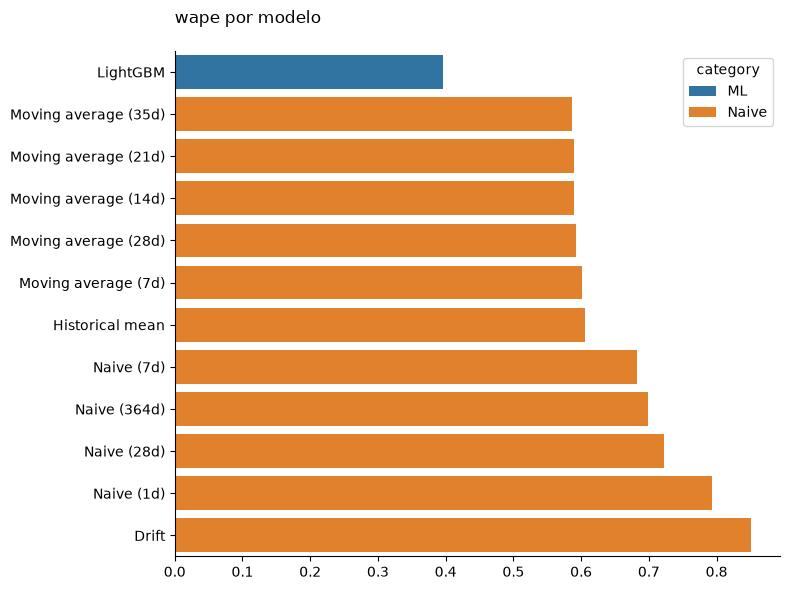

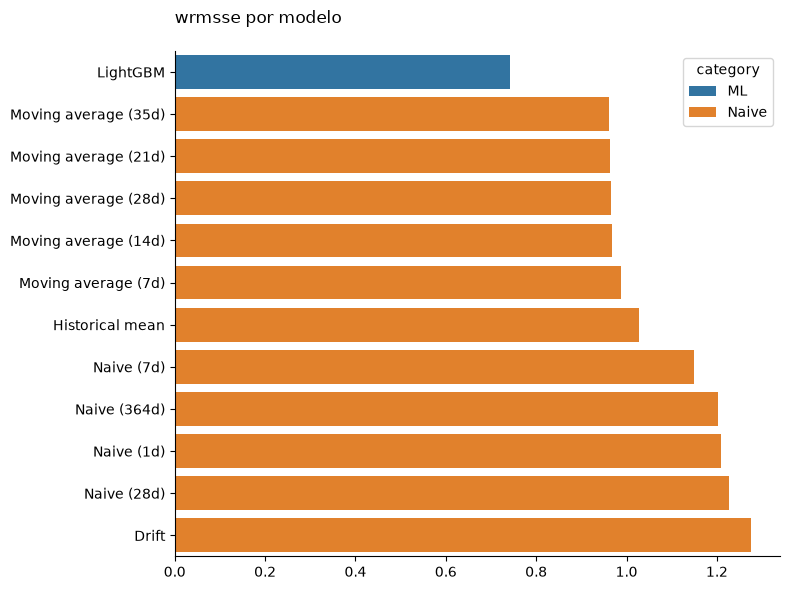

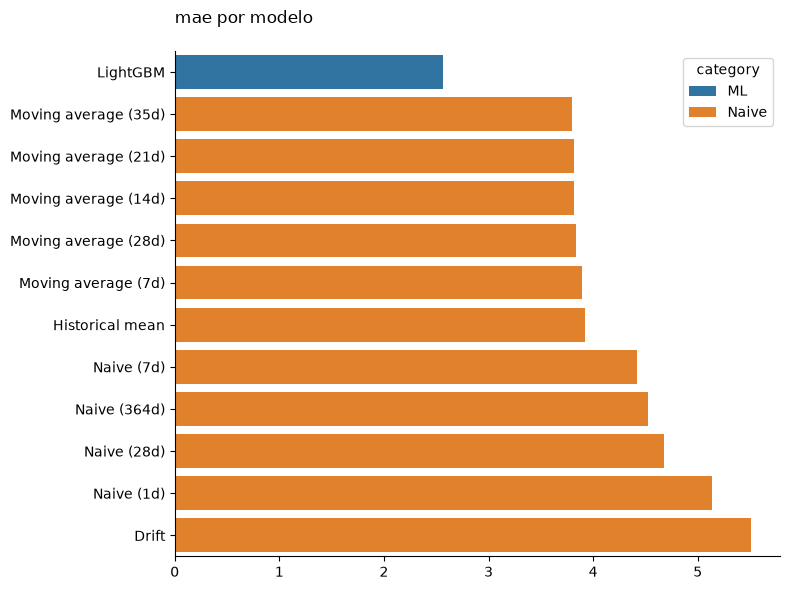

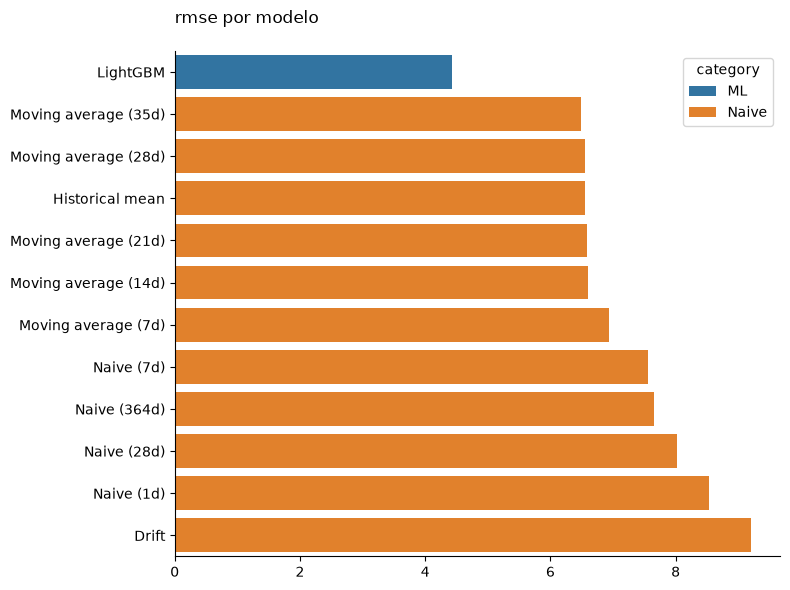

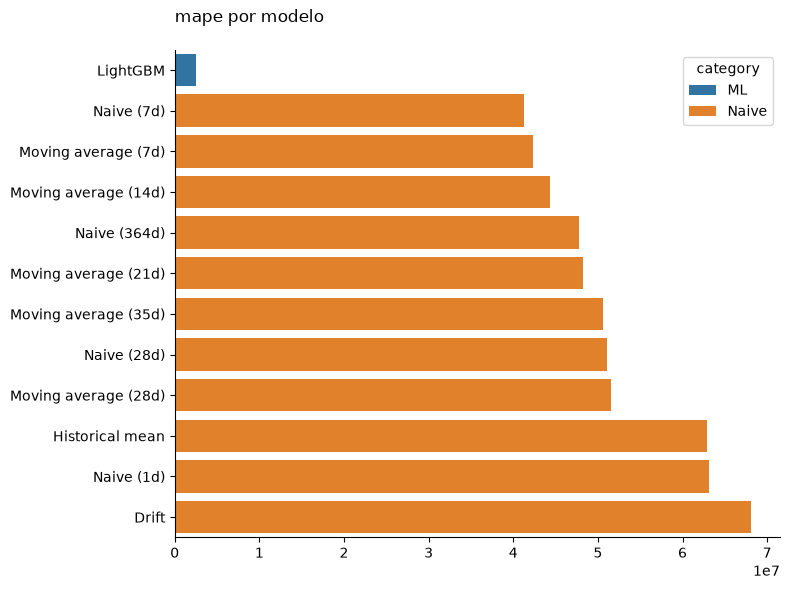

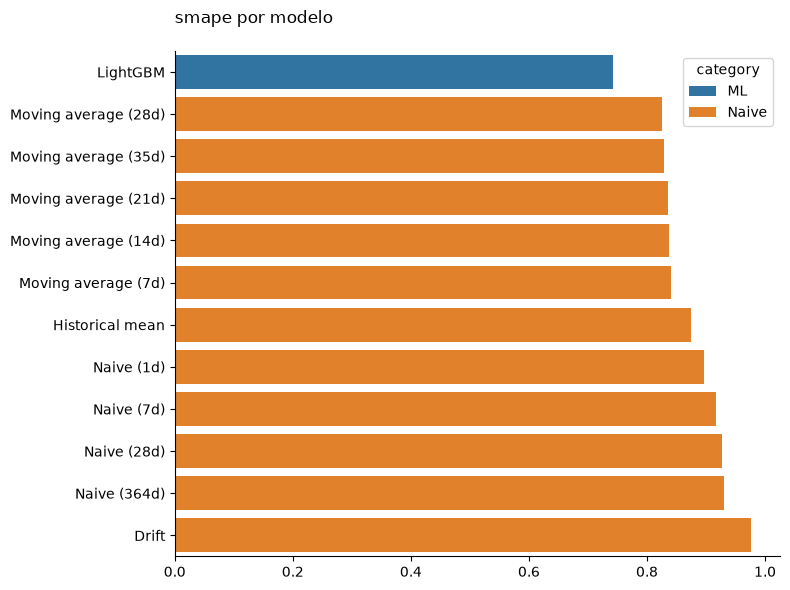

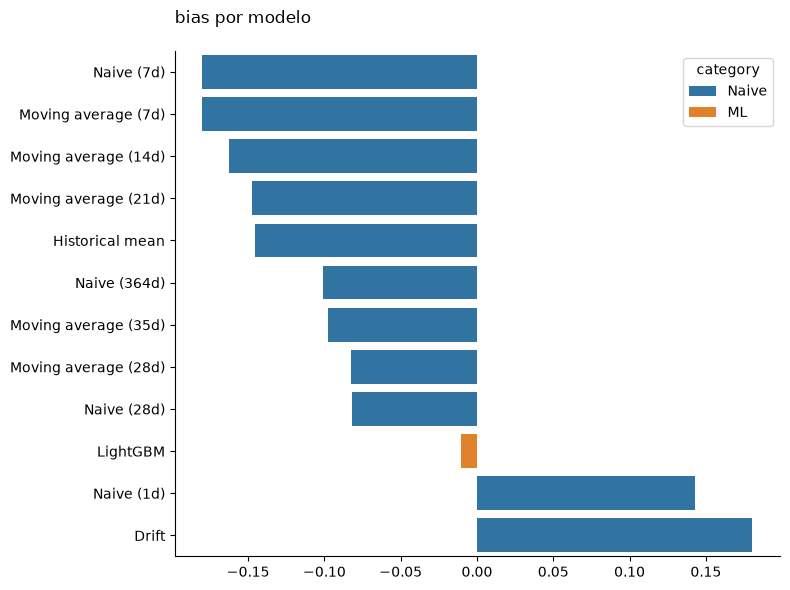

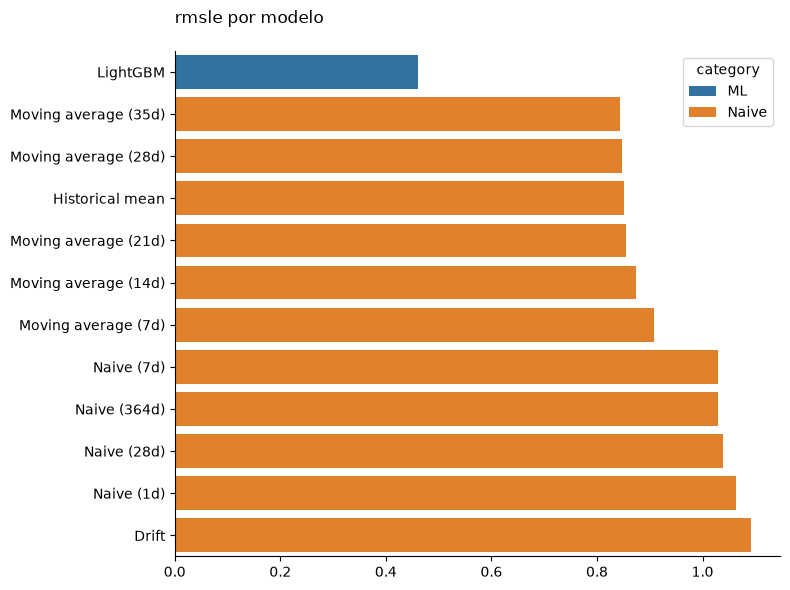

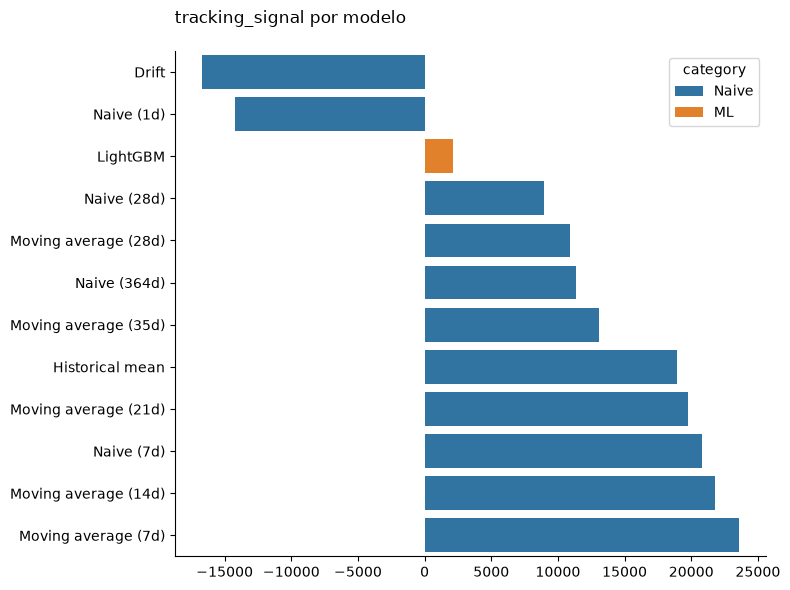

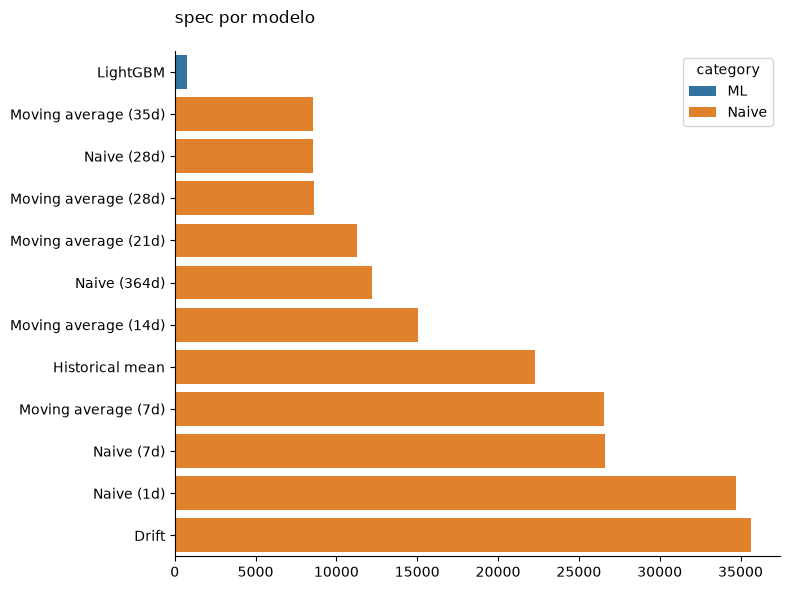

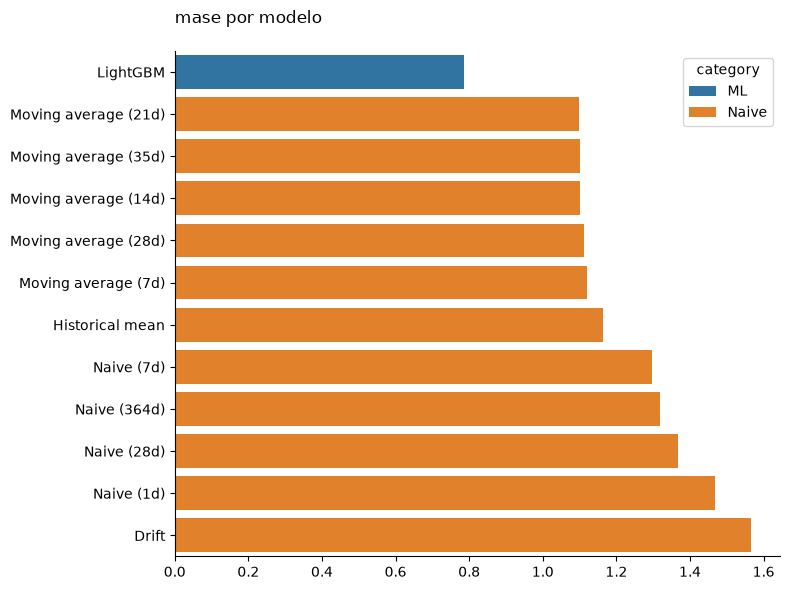

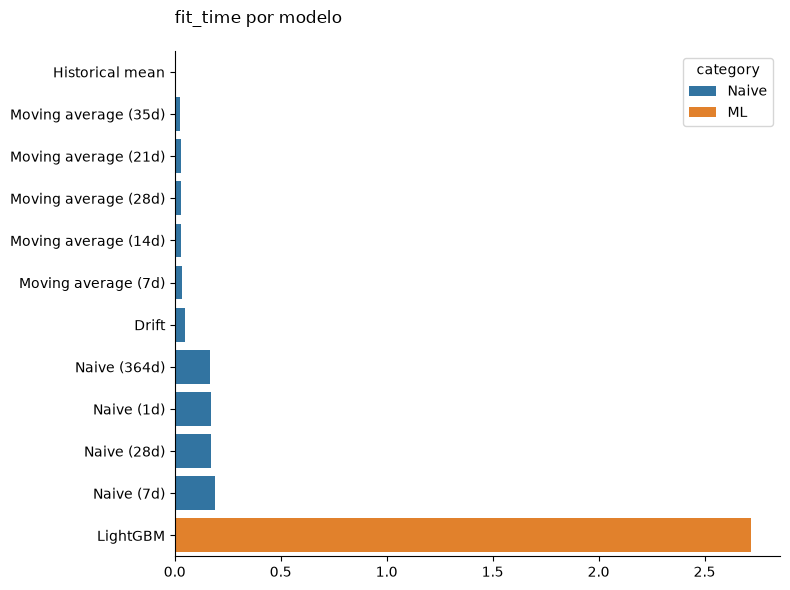

In [20]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

# Selección de features

El resto del notebook usa LightGBM (velocidad, soporte nativo de categóricas, compatible con SHAP), así que la selección se hace sobre `lgbm_model`. Se comparan dos criterios de importancia (gain del árbol vs. permutation importance sobre validación) y luego se aplica una eliminación hacia atrás (backward elimination): se van descartando las features menos importantes mientras el WRMSSE de validación no empeore más allá de una tolerancia.

## Importancia por ganancia (gain)

In [21]:
importance_gain = (
    pd.Series(lgbm_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)
importance_gain.head(20)

rolling_mean_lag7_window_size14     5.008813e+07
lag1                                2.570309e+07
rolling_mean_lag7_window_size7      1.890879e+07
avg_sell_price                      8.934252e+06
lag2                                5.925515e+06
item_id                             3.708488e+06
lag3                                2.853420e+06
price_vs_mean                       1.762112e+06
lag7                                1.745617e+06
dayofweek                           1.562315e+06
dow_sin                             5.860320e+05
price_change                        5.401268e+05
lag14                               4.658536e+05
dow_cos                             4.388210e+05
rolling_mean_lag28_window_size28    4.220397e+05
price_vs_max                        3.054659e+05
event_name_1                        2.066896e+05
days_since_event                    2.008634e+05
lag21                               1.899449e+05
doy_sin                             1.592364e+05
dtype: float64

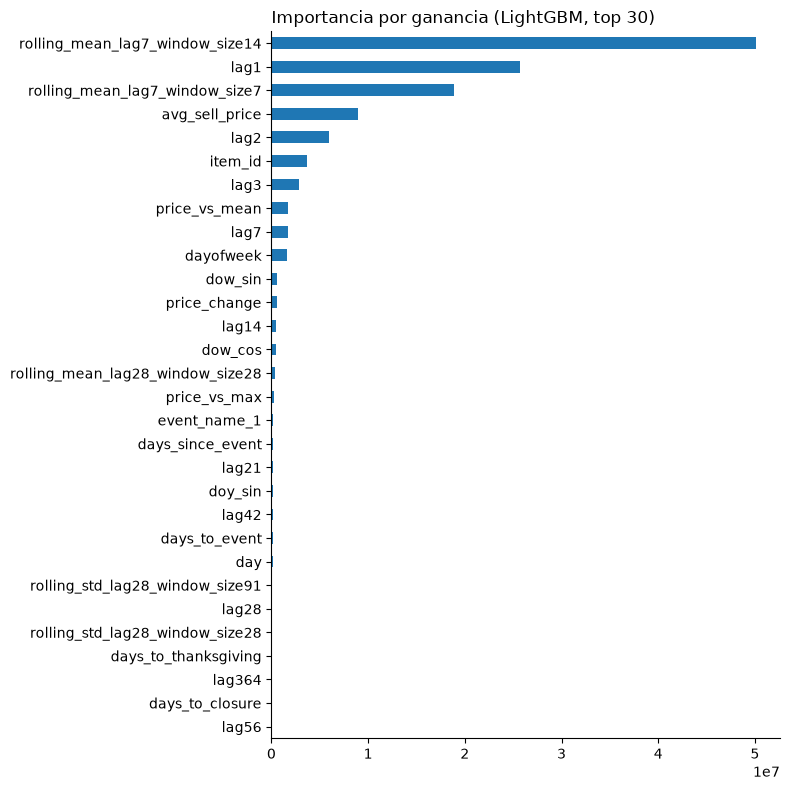

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_gain.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Importancia por ganancia (LightGBM, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Permutation importance

El gain puede sobreestimar features de alta cardinalidad o muy usadas para splits sin aportar demasiado al error final. La permutation importance mide directamente cuánto empeora el RMSE en validación al mezclar (shuffle) cada columna, así que es un criterio más fiel al desempeño real del modelo.

In [25]:
from src.modeling import compute_permutation_importance

importance_perm = compute_permutation_importance(
    lgbm_model, X_valid, y_valid, FEATURES,
    sample_size=300_000, n_repeats=5, random_state=RANDOM_STATE,
)
importance_perm.head(20)

lag1                                1.131878
rolling_mean_lag7_window_size14     0.634066
avg_sell_price                      0.460279
lag2                                0.252701
item_id                             0.238430
dayofweek                           0.174749
price_vs_mean                       0.134612
lag3                                0.108427
rolling_mean_lag7_window_size7      0.088012
price_change                        0.079269
lag7                                0.057541
dow_sin                             0.044780
price_vs_max                        0.038064
rolling_mean_lag28_window_size28    0.025884
dow_cos                             0.024320
lag14                               0.016362
event_name_1                        0.011502
doy_cos                             0.010420
days_to_closure                     0.010058
lag42                               0.009252
dtype: float64

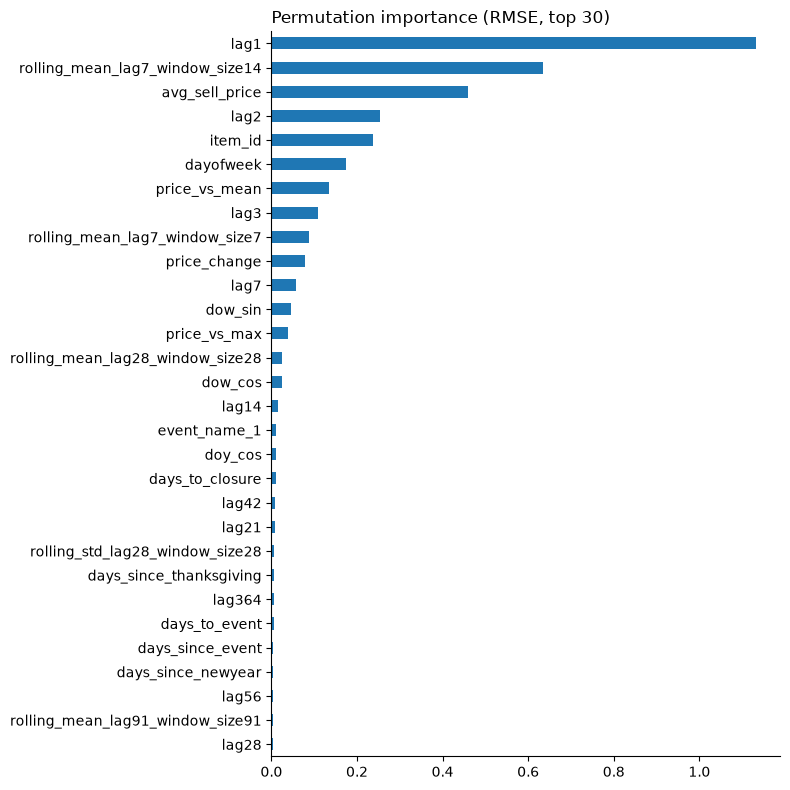

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_perm.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Permutation importance (RMSE, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Eliminación hacia atrás (backward elimination)

Se parte del ranking de permutation importance (de menor a mayor) y se intenta eliminar cada feature: si reentrenar sin ella no empeora el WRMSSE de validación más allá de `TOLERANCE`, se descarta definitivamente.

In [29]:
from src.modeling import backward_feature_selection

selected_features, final_wrmsse, log_df = backward_feature_selection(
    X_train, y_train, X_valid, train, valid,
    FEATURES, CATEGORICAL_FEATURES, importance_perm,
    tolerance=0.0, random_state=RANDOM_STATE,
)

2026-08-23 17:49:25.708 | INFO     | src.modeling.feature_selection:backward_feature_selection:80 - Baseline (104 features): WRMSSE=0.7417
2026-08-23 17:49:28.704 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_std_lag28_window_size7' -> 103 features | WRMSSE=0.7413
2026-08-23 17:49:32.004 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'rolling_std_lag91_window_size91' | WRMSSE empeoraría a 0.7419
2026-08-23 17:49:34.840 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'rolling_min_lag364_window_size91' | WRMSSE empeoraría a 0.7414
2026-08-23 17:49:37.182 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'days_to_thanksgiving' -> 102 features | WRMSSE=0.7399
2026-08-23 17:49:40.386 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'days_to_newyear' | WRMSSE empeoraría a 0.7409
2026-08-23 17:4

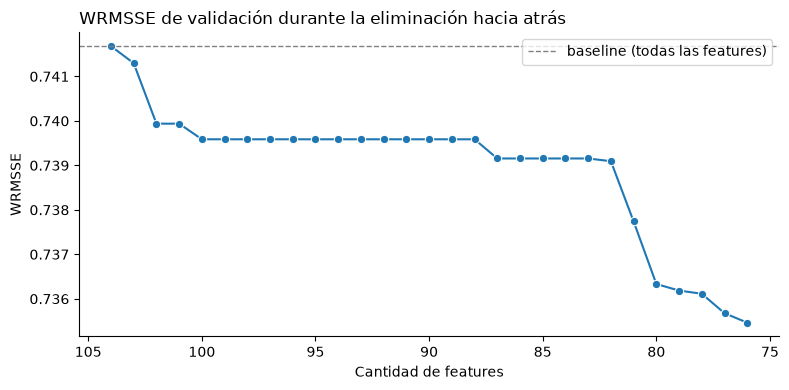

In [30]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

## Features seleccionadas

Se fija `FEATURES` (y las variables derivadas `X_train`/`X_valid`/`X_test`/`CATEGORICAL_FEATURES`/`NUMERICAL_FEATURES`) al subconjunto seleccionado, para que el resto del notebook (modelo simple, SHAP, tuning con Optuna, modelo final) entrene sobre las features filtradas.

In [31]:
print(f"Features descartadas ({len(FEATURES) - len(selected_features)}): "
      f"{sorted(set(FEATURES) - set(selected_features))}")

FEATURES = selected_features
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in FEATURES]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in FEATURES]

X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]
X_test = X_test[FEATURES]

print(f"Features finales: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categóricas)")

Features descartadas (28): ['avg_sell_price', 'cat_id', 'days_to_event', 'days_to_thanksgiving', 'dept_id', 'event_name_2', 'event_type_1', 'event_type_2', 'event_type_2_enc', 'has_event', 'has_event_2', 'is_month_end', 'is_month_start', 'is_store_closed', 'is_weekend', 'month_cos', 'quarter', 'rolling_max_lag28_window_size91', 'rolling_mean_lag364_window_size28', 'rolling_mean_lag7_window_size14', 'rolling_mean_lag91_window_size28', 'rolling_min_lag28_window_size91', 'rolling_std_lag28_window_size7', 'snap', 'state_id', 'store_id', 'year', 'zero_streak']
Features finales: 76 (2 categóricas)


# Modelo con variables seleccionadas

In [32]:
from src.evaluation import make_wrmsse_metric

wrmsse_metric = make_wrmsse_metric(train, valid)

In [35]:
model = LGBMRegressor(
    objective="rmse",
)

t0 = time.perf_counter()
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features)", model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's rmse: 5.43312	valid_0's wrmsse: 0.881306
[20]	valid_0's rmse: 4.66252	valid_0's wrmsse: 0.774814
[30]	valid_0's rmse: 4.5071	valid_0's wrmsse: 0.752087
[40]	valid_0's rmse: 4.465	valid_0's wrmsse: 0.745459
[50]	valid_0's rmse: 4.45186	valid_0's wrmsse: 0.743123
[60]	valid_0's rmse: 4.44265	valid_0's wrmsse: 0.741647
[70]	valid_0's rmse: 4.43661	valid_0's wrmsse: 0.740425
[80]	valid_0's rmse: 4.43341	valid_0's wrmsse: 0.739418
[90]	valid_0's rmse: 4.43159	valid_0's wrmsse: 0.738657
[100]	valid_0's rmse: 4.42881	valid_0's wrmsse: 0.737668
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 4.42881	valid_0's wrmsse: 0.737668
Evaluated only: rmse


2026-08-23 18:05:59.996 | INFO     | src.evaluation.metrics:evaluate_predictions:354 - LightGBM (selected features) [ML] | WAPE: 39.61% | WRMSSE: 0.7377 | MAE: 2.565 | RMSE: 4.427 | MAPE: 259592369.64% | SMAPE: 74.28% | Bias: -0.74% | RMSLE: 0.4597 | TS: 1472.40 | SPEC: 522.581 | MASE: 0.7822 | fit: 4.14s


{'model': 'LightGBM (selected features)',
 'category': 'ML',
 'wape': 0.3961048555918562,
 'wrmsse': 0.7376683654828765,
 'mae': 2.5648743990168357,
 'rmse': 4.4268442728981325,
 'mape': 2595923.6964302226,
 'smape': 0.7428355124345412,
 'bias': -0.007397552721053698,
 'rmsle': 0.45973873364673595,
 'tracking_signal': 1472.3956252857013,
 'spec': 522.5810493780995,
 'mase': 0.7822060812033541,
 'fit_time': 4.138643989001139}

## Explicación modelo

In [36]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(30_000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                              feature  mean_abs_shap
41     rolling_mean_lag7_window_size7       1.821553
4                       price_vs_mean       1.249123
28                               lag1       1.173131
0                             item_id       0.585217
29                               lag2       0.537945
..                                ...            ...
63    rolling_min_lag91_window_size91       0.000899
65               expanding_mean_lag91       0.000853
13                   event_type_1_enc       0.000762
19                   price_volatility       0.000410
74  rolling_mean_lag365_window_size28       0.000315

[76 rows x 2 columns]


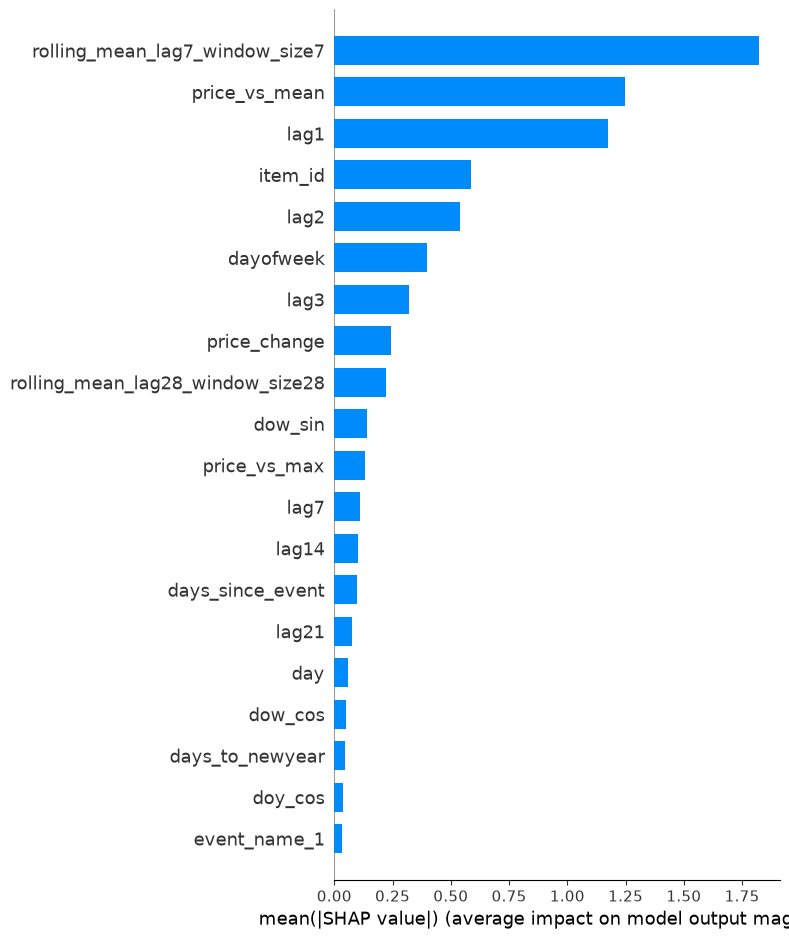

In [37]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


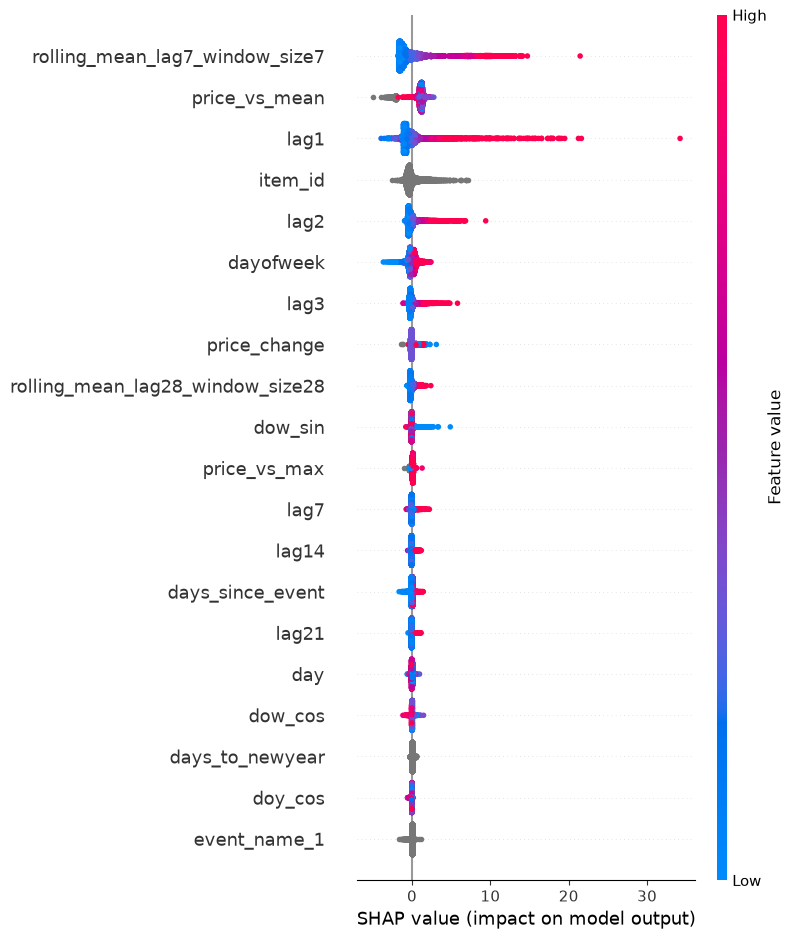

In [38]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [39]:
from src.evaluation import plot_forecast
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, TARGET, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [40]:
from src.evaluation.metrics import build_predictions_report

metrics_test, df_pred = build_predictions_report(train, test, y_test, model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test['wrmsse']:.4f}")

Test WAPE: 39.68%
Test WRMSSE: 0.7645


# Modelo optimizado

In [41]:
import optuna
from optuna.integration import LightGBMPruningCallback

In [42]:
def objective(trial):
    params = dict(
        objective=OBJECTIVE,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        n_estimators=1500,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    if OBJECTIVE == "tweedie":
        params["tweedie_variance_power"] = trial.suggest_float(
            "tweedie_variance_power", 1.1, 1.9
        )

    eval_metric = "tweedie" if OBJECTIVE == "tweedie" else "rmse"

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric=eval_metric,
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(30, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, eval_metric),
        ],
    )

    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    return final_wrmsse

In [43]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5),
)

study.optimize(
    objective,
    n_trials=1_000,
    timeout=60 * 10,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

[I 2026-08-23 18:06:09,686] Using an existing study with name 'study_level_12_daily_item_store' instead of creating a new one.


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-08-23 18:06:12,794] Trial 177 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:15,485] Trial 178 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:18,296] Trial 179 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:20,913] Trial 180 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:23,266] Trial 181 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:26,076] Trial 182 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:28,668] Trial 183 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:31,312] Trial 184 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:33,196] Trial 185 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:06:35,712] Trial 186 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:09:47,246] Trial 269 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:09:49,120] Trial 270 pruned. Trial was pruned at iteration 10.
[I 2026-08-23 18:09:51,329] Trial 271 pr

# Modelo final

In [44]:
model_params = best_trial.params

final_model = lgb.LGBMRegressor(
    objective=OBJECTIVE,
    n_estimators=3_000,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

t0 = time.perf_counter()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features | Optuna)", final_model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's tweedie: 7.42365	valid_0's wrmsse: 1.00781
[20]	valid_0's tweedie: 7.06581	valid_0's wrmsse: 0.854555
[30]	valid_0's tweedie: 6.92979	valid_0's wrmsse: 0.774751
[40]	valid_0's tweedie: 6.87178	valid_0's wrmsse: 0.745635
[50]	valid_0's tweedie: 6.84824	valid_0's wrmsse: 0.736829
[60]	valid_0's tweedie: 6.83605	valid_0's wrmsse: 0.733003
[70]	valid_0's tweedie: 6.83076	valid_0's wrmsse: 0.731723
[80]	valid_0's tweedie: 6.82875	valid_0's wrmsse: 0.731224
[90]	valid_0's tweedie: 6.82741	valid_0's wrmsse: 0.730368
[100]	valid_0's tweedie: 6.827	valid_0's wrmsse: 0.730102
[110]	valid_0's tweedie: 6.82673	valid_0's wrmsse: 0.730205
[120]	valid_0's tweedie: 6.82673	valid_0's wrmsse: 0.73005
[130]	valid_0's tweedie: 6.82691	valid_0's wrmsse: 0.730125
[140]	valid_0's tweedie: 6.82697	valid_0's wrmsse: 0.729797
[150]	valid_0's tweedie: 6.82698	valid_0's wrmsse: 0.729469
[160]	valid_0's tweedie: 6.82709	valid_0's wrmsse: 

2026-08-23 18:16:31.990 | INFO     | src.evaluation.metrics:evaluate_predictions:354 - LightGBM (selected features | Optuna) [ML] | WAPE: 38.39% | WRMSSE: 0.7300 | MAE: 2.486 | RMSE: 4.382 | MAPE: 56.12% | SMAPE: 38.17% | Bias: -3.31% | RMSLE: 0.4415 | TS: 6807.47 | SPEC: 738.649 | MASE: 0.7610 | fit: 19.37s


{'model': 'LightGBM (selected features | Optuna)',
 'category': 'ML',
 'wape': 0.38388270436406535,
 'wrmsse': 0.7299583100953864,
 'mae': 2.485733024346655,
 'rmse': 4.382020531552463,
 'mape': 0.5611555484225567,
 'smape': 0.3817074725222582,
 'bias': -0.03314647928640289,
 'rmsle': 0.4415317063524722,
 'tracking_signal': 6807.465919229435,
 'spec': 738.6490150021868,
 'mase': 0.7609632800517487,
 'fit_time': 19.365929862000485}

## Resultados finales

In [45]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
metrics_test_final, df_pred = build_predictions_report(train, test, y_test, final_model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 39.04%
Test WRMSSE: 0.7609


# Exportar

In [46]:
import joblib

feature_importance = (
    pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)

# No se guardan df/X_train/y_train/X_valid/y_valid/valid: reconstruibles desde el
# parquet en data/datasets/ + este mismo notebook, y notebooks/03_predictions.ipynb
# no los usa -- guardarlos solo triplicaba el tamaño del artifact (y el pico de RAM
# al armarlo) sin necesidad, justo lo que hace fallar por memoria al nivel 12.
artifact = {
    # modelo y datos de trabajo
    "level": LEVEL,
    "objective": OBJECTIVE,
    "model": final_model,
    "model_params": model_params,
    "metrics_results": results_df,
    "X_test": X_test,
    "y_test": y_test,
    "train": train,
    "test": test,
    # features y columnas
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "id_cols": ID_COLS,
    "leaky_cols": LEAKY_COLS,
    "target": TARGET,
    "feature_importance": feature_importance,
    # predicciones y métricas del modelo final (test)
    #"df_pred": df_pred,
    #"df_metrics": df_metrics,
    # comparación de todos los modelos probados (validación)
    "model_results": model_results,
    "results_df": results_df,
    #"series_metrics_valid": series_metrics_df,
    # metadatos
    "wape_valid": model_results[-1]["wape"],
    "wrmsse_valid": model_results[-1]["wrmsse"],
    "wape_test": metrics_test_final["wape"],
    "wrmsse_test": metrics_test_final["wrmsse"],
    "train_start": str(first_date.date()),
    "valid_start": str(valid_start.date()),
    "test_start": str(test_start.date()),
}

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
joblib.dump(artifact, artifact_path)
print(f"Artifact guardado en {artifact_path}")

Artifact guardado en ../artifacts/models/level_12_daily_item_store_sales_artifact.pkl
